Mounted at /content/drive
Dataset shape: (545, 13)


Problem 3a
Scaling Method: Standardization
Lambda: 1.0
Training samples: 436
Validation samples: 109
Iterations: 1000
Learning rates tested: [0.01, 0.025, 0.05, 0.075, 0.1]

Learning Rate = 0.01
Final Training Loss = 676215895949.2219
Final Validation Loss = 1146981855515.4321

Learning Rate = 0.025
Final Training Loss = 676215509548.8943
Final Validation Loss = 1146933656842.04

Learning Rate = 0.05
Final Training Loss = 676215509548.8854
Final Validation Loss = 1146933652803.8298

Learning Rate = 0.075
Final Training Loss = 676215509548.8853
Final Validation Loss = 1146933652803.8276

Learning Rate = 0.1
Final Training Loss = 676215509548.8853
Final Validation Loss = 1146933652803.8276


----------------------------------------------------------------------
BEST RESULT
----------------------------------------------------------------------
Problem: Problem 3a
Best Learning Rate: 0.075
Lambda: 1.0
Final Training Loss: 676215509548.88

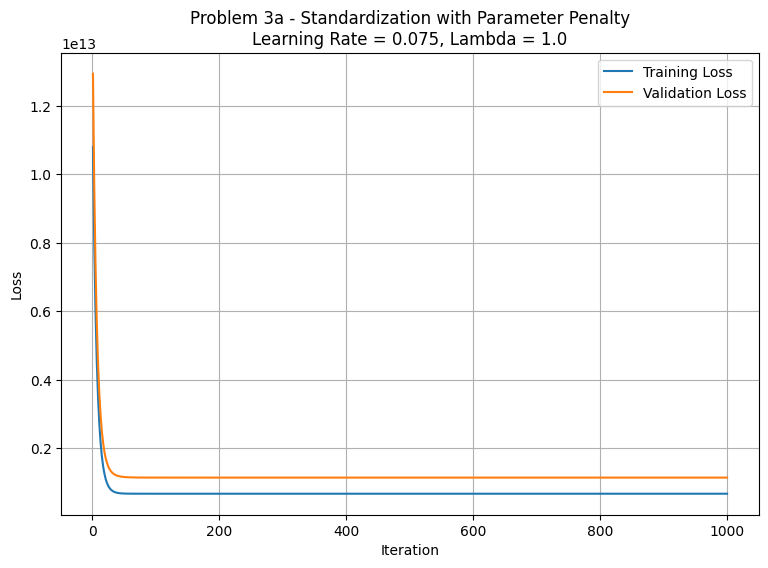



PROBLEM 3a VS PROBLEM 2a


,Method,Best Learning Rate,Final Training Loss,Final Validation Loss
0,Problem 2a - Standardization,0.100,6.750041e+11,1.146361e+12
1,Problem 3a - Standardization with Penalty,0.075,6.762155e+11,1.146934e+12




Problem 3b
Scaling Method: Standardization
Lambda: 1.0
Training samples: 436
Validation samples: 109
Iterations: 1000
Learning rates tested: [0.01, 0.025, 0.05, 0.075, 0.1]

Learning Rate = 0.01
Final Training Loss = 497440567844.7416
Final Validation Loss = 900418801475.2324

Learning Rate = 0.025
Final Training Loss = 497436726524.0418
Final Validation Loss = 900690924065.828

Learning Rate = 0.05
Final Training Loss = 497436726500.5351
Final Validation Loss = 900691360782.4967

Learning Rate = 0.075
Final Training Loss = 497436726500.5351
Final Validation Loss = 900691360801.0671

Learning Rate = 0.1
Final Training Loss = 497436726500.5351
Final Validation Loss = 900691360801.0679


----------------------------------------------------------------------
BEST RESULT
----------------------------------------------------------------------
Problem: Problem 3b
Best Learning Rate: 0.01
Lambda: 1.0
Final Training Loss: 497440567844.7416
Final Validation Loss: 900418801475.2324

Best Parame

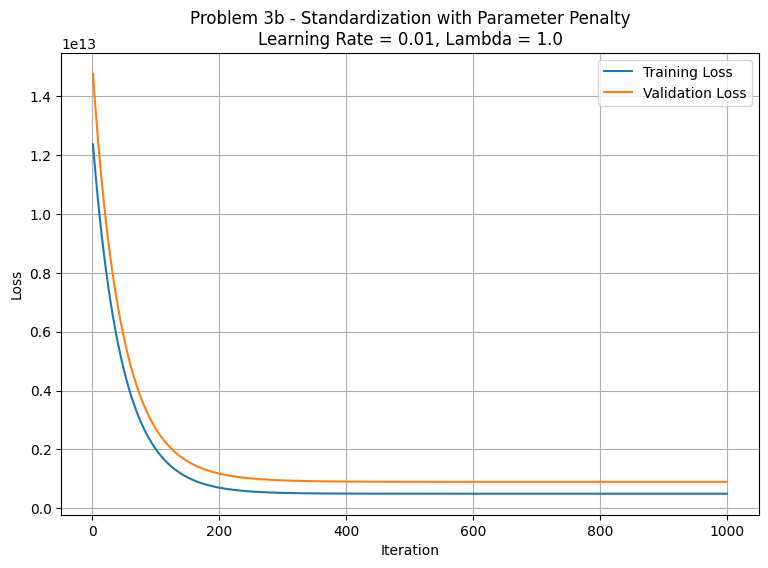



PROBLEM 3b VS PROBLEM 2b


,Method,Best Learning Rate,Final Training Loss,Final Validation Loss
0,Problem 2b - Standardization,0.01,4.962445e+11,9.001114e+11
1,Problem 3b - Standardization with Penalty,0.01,4.974406e+11,9.004188e+11


In [1]:
# ============================================================
# HOMEWORK 2 - PROBLEM 3
# Regularized Linear Regression using Gradient Descent
# Gradient Descent Implemented From Scratch
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ============================================================
# LOAD DATASET
# ============================================================

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Housing.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# ============================================================
# CONVERT YES/NO VARIABLES TO 1/0
# ============================================================

yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in yes_no_columns:
    df[column] = df[column].map({
        'yes': 1,
        'no': 0
    })


# ============================================================
# EVALUATION LOSS
# No regularization penalty is added here
# ============================================================

def compute_evaluation_loss(X, y, theta):

    m = len(y)

    predictions = X @ theta
    errors = predictions - y

    loss = (1 / (2 * m)) * np.sum(errors ** 2)

    return loss


# ============================================================
# TRAINING LOSS WITH PARAMETER PENALTY
# theta_0 is NOT penalized
# ============================================================

def compute_training_loss(X, y, theta, lambda_reg):

    m = len(y)

    predictions = X @ theta
    errors = predictions - y

    # Normal squared error loss
    squared_error = np.sum(errors ** 2)

    # Parameter penalty
    # theta_0 is excluded
    penalty = lambda_reg * np.sum(theta[1:] ** 2)

    # Regularized training loss
    loss = (1 / (2 * m)) * (
        squared_error + penalty
    )

    return loss


# ============================================================
# GRADIENT DESCENT WITH PARAMETER PENALTY
# ============================================================

def gradient_descent_regularized(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    iterations,
    lambda_reg
):

    m = len(y_train)

    # Add column of ones for theta_0
    X_train_bias = np.c_[
        np.ones(m),
        X_train
    ]

    X_val_bias = np.c_[
        np.ones(len(y_val)),
        X_val
    ]

    # Initialize all parameters to zero
    theta = np.zeros(
        X_train_bias.shape[1]
    )

    train_losses = []
    val_losses = []

    for i in range(iterations):

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        predictions = X_train_bias @ theta

        # ----------------------------------------------------
        # Error
        # ----------------------------------------------------

        errors = predictions - y_train

        # ----------------------------------------------------
        # Gradient for theta_0
        # No regularization for theta_0
        # ----------------------------------------------------

        gradient = (
            1 / m
        ) * (
            X_train_bias.T @ errors
        )

        # ----------------------------------------------------
        # Add regularization penalty to theta_1, theta_2, ...
        # ----------------------------------------------------

        gradient[1:] = (
            gradient[1:]
            +
            (lambda_reg / m) * theta[1:]
        )

        # ----------------------------------------------------
        # Update parameters
        # ----------------------------------------------------

        theta = (
            theta
            -
            learning_rate * gradient
        )

        # ----------------------------------------------------
        # TRAINING LOSS
        # Includes regularization penalty
        # ----------------------------------------------------

        train_loss = compute_training_loss(
            X_train_bias,
            y_train,
            theta,
            lambda_reg
        )

        # ----------------------------------------------------
        # VALIDATION LOSS
        # No regularization penalty
        # ----------------------------------------------------

        val_loss = compute_evaluation_loss(
            X_val_bias,
            y_val,
            theta
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses


# ============================================================
# RUN REGULARIZED EXPERIMENT
# ============================================================

def run_regularized_experiment(
    X,
    y,
    feature_names,
    problem_name,
    learning_rates,
    iterations,
    lambda_reg
):

    # ========================================================
    # 80/20 TRAINING AND VALIDATION SPLIT
    # ========================================================

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    X_train = np.array(
        X_train,
        dtype=float
    )

    X_val = np.array(
        X_val,
        dtype=float
    )

    y_train = np.array(
        y_train,
        dtype=float
    )

    y_val = np.array(
        y_val,
        dtype=float
    )


    # ========================================================
    # STANDARDIZATION
    # Best scaling approach from Problem 2
    # ========================================================

    scaler = StandardScaler()

    # Fit only on training data
    X_train_scaled = scaler.fit_transform(
        X_train
    )

    # Apply same transformation to validation data
    X_val_scaled = scaler.transform(
        X_val
    )


    print("\n")
    print("=" * 70)
    print(problem_name)
    print("=" * 70)

    print("Scaling Method: Standardization")
    print("Lambda:", lambda_reg)
    print("Training samples:", len(X_train_scaled))
    print("Validation samples:", len(X_val_scaled))
    print("Iterations:", iterations)
    print("Learning rates tested:", learning_rates)


    results = {}


    # ========================================================
    # TEST LEARNING RATES
    # ========================================================

    for alpha in learning_rates:

        theta, train_losses, val_losses = gradient_descent_regularized(
            X_train_scaled,
            y_train,
            X_val_scaled,
            y_val,
            learning_rate=alpha,
            iterations=iterations,
            lambda_reg=lambda_reg
        )

        final_train_loss = train_losses[-1]
        final_val_loss = val_losses[-1]

        results[alpha] = {
            'theta': theta,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'final_train_loss': final_train_loss,
            'final_val_loss': final_val_loss
        }

        print("\nLearning Rate =", alpha)

        print(
            "Final Training Loss =",
            final_train_loss
        )

        print(
            "Final Validation Loss =",
            final_val_loss
        )


    # ========================================================
    # SELECT BEST LEARNING RATE
    # Lowest final validation loss
    # ========================================================

    best_alpha = min(
        results,
        key=lambda alpha:
        results[alpha]['final_val_loss']
    )

    best_result = results[
        best_alpha
    ]

    best_theta = best_result[
        'theta'
    ]


    # ========================================================
    # PRINT BEST RESULT
    # ========================================================

    print("\n")
    print("-" * 70)
    print("BEST RESULT")
    print("-" * 70)

    print("Problem:", problem_name)

    print(
        "Best Learning Rate:",
        best_alpha
    )

    print(
        "Lambda:",
        lambda_reg
    )

    print(
        "Final Training Loss:",
        best_result['final_train_loss']
    )

    print(
        "Final Validation Loss:",
        best_result['final_val_loss']
    )


    # ========================================================
    # PRINT PARAMETERS
    # ========================================================

    print("\nBest Parameters:")

    print(
        "theta_0 (intercept) =",
        best_theta[0]
    )

    for i, feature in enumerate(feature_names):

        print(
            f"theta_{i+1} ({feature}) =",
            best_theta[i+1]
        )


    # ========================================================
    # PLOT TRAINING AND VALIDATION LOSSES
    # ========================================================

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        range(1, iterations + 1),
        best_result['train_losses'],
        label='Training Loss'
    )

    plt.plot(
        range(1, iterations + 1),
        best_result['val_losses'],
        label='Validation Loss'
    )

    plt.xlabel(
        'Iteration'
    )

    plt.ylabel(
        'Loss'
    )

    plt.title(
        f'{problem_name} - Standardization with Parameter Penalty\n'
        f'Learning Rate = {best_alpha}, Lambda = {lambda_reg}'
    )

    plt.legend()

    plt.grid(True)

    plt.show()


    return {
        'best_alpha': best_alpha,
        'lambda': lambda_reg,
        'theta': best_theta,
        'train_loss':
            best_result['final_train_loss'],
        'val_loss':
            best_result['final_val_loss']
    }


# ============================================================
# SETTINGS
# ============================================================

learning_rates = [
    0.01,
    0.025,
    0.05,
    0.075,
    0.1
]

iterations = 1000

# Parameter penalty strength
lambda_reg = 1.0

y = df[
    'price'
].values


# ============================================================
# PROBLEM 3a
# Repeat Problem 2a with Parameter Penalty
# Best scaling from Problem 2a = Standardization
# ============================================================

features_3a = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

X_3a = df[
    features_3a
].values


result_3a = run_regularized_experiment(
    X=X_3a,
    y=y,
    feature_names=features_3a,
    problem_name='Problem 3a',
    learning_rates=learning_rates,
    iterations=iterations,
    lambda_reg=lambda_reg
)


# ============================================================
# COMPARE PROBLEM 3a WITH PROBLEM 2a
# ============================================================

print("\n")
print("=" * 70)
print("PROBLEM 3a VS PROBLEM 2a")
print("=" * 70)

comparison_3a = pd.DataFrame({

    'Method': [
        'Problem 2a - Standardization',
        'Problem 3a - Standardization with Penalty'
    ],

    'Best Learning Rate': [
        0.1,
        result_3a['best_alpha']
    ],

    'Final Training Loss': [
        675004105663.2902,
        result_3a['train_loss']
    ],

    'Final Validation Loss': [
        1146360772862.6836,
        result_3a['val_loss']
    ]

})

display(comparison_3a)


# ============================================================
# PROBLEM 3b
# Repeat Problem 2b with Parameter Penalty
# Best training scaling from Problem 2b = Standardization
# ============================================================

features_3b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_3b = df[
    features_3b
].values


result_3b = run_regularized_experiment(
    X=X_3b,
    y=y,
    feature_names=features_3b,
    problem_name='Problem 3b',
    learning_rates=learning_rates,
    iterations=iterations,
    lambda_reg=lambda_reg
)


# ============================================================
# COMPARE PROBLEM 3b WITH PROBLEM 2b
# ============================================================

print("\n")
print("=" * 70)
print("PROBLEM 3b VS PROBLEM 2b")
print("=" * 70)

comparison_3b = pd.DataFrame({

    'Method': [
        'Problem 2b - Standardization',
        'Problem 3b - Standardization with Penalty'
    ],

    'Best Learning Rate': [
        0.01,
        result_3b['best_alpha']
    ],

    'Final Training Loss': [
        496244544318.54205,
        result_3b['train_loss']
    ],

    'Final Validation Loss': [
        900111363844.0186,
        result_3b['val_loss']
    ]

})

display(comparison_3b)